# Analyse des Distributions Horaires

Ce notebook permet de comparer la distribution heure par heure des différentes sources de données énergétiques. L'objectif est d'identifier la dynamique journalière de chaque variable et de détecter d'éventuels décalages temporels (fuseaux horaires différents, latence de déclaration) entre nos sources.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration graphique sobre
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 18)

# 1. Chargement des données nettoyées
df = pd.read_csv('../output/solarflow_cleaned_2026-01-01_2026-04-27.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Extraction de l'heure (0-23)
df['heure'] = df['timestamp'].dt.hour

print(f"Données prêtes : {len(df)} enregistrements.")
print("Note : Les valeurs NaN éventuelles (ex: source CSV en janvier) seront automatiquement ignorées par Seaborn lors de la création des boxplots.")

Données prêtes : 2808 enregistrements.
Note : Les valeurs NaN éventuelles (ex: source CSV en janvier) seront automatiquement ignorées par Seaborn lors de la création des boxplots.


## Visualisation des Boîtes à Moustaches par Heure

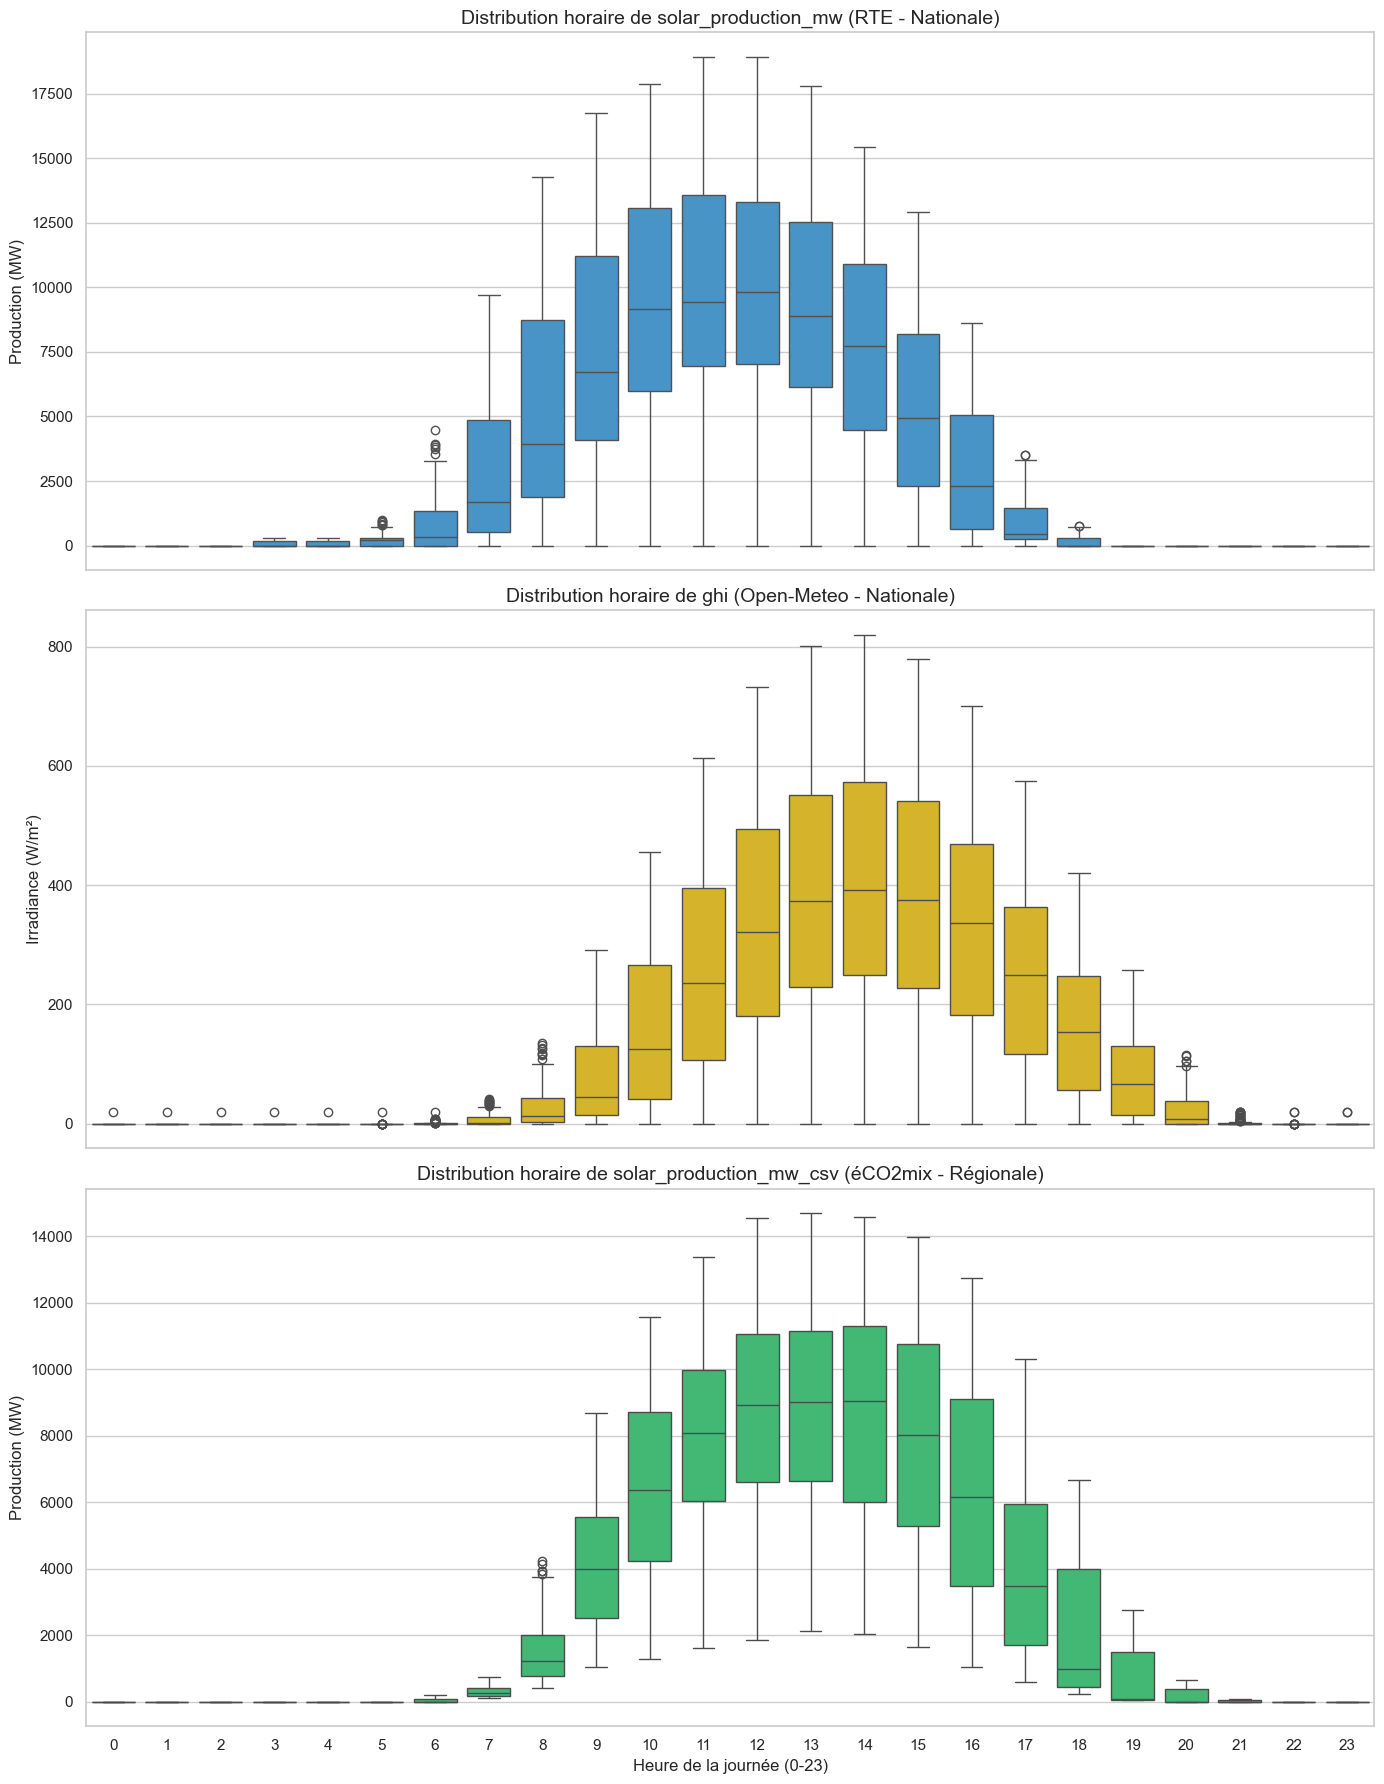

In [2]:
fig, axes = plt.subplots(3, 1, sharex=True)

# Graphique 1 : Production Solaire RTE (Nationale)
sns.boxplot(data=df, x='heure', y='solar_production_mw', ax=axes[0], color="#3498db")
axes[0].set_title('Distribution horaire de solar_production_mw (RTE - Nationale)', fontsize=14)
axes[0].set_ylabel('Production (MW)')
axes[0].set_xlabel('')

# Graphique 2 : Irradiance GHI (Météo)
sns.boxplot(data=df, x='heure', y='ghi', ax=axes[1], color="#f1c40f")
axes[1].set_title('Distribution horaire de ghi (Open-Meteo - Nationale)', fontsize=14)
axes[1].set_ylabel('Irradiance (W/m²)')
axes[1].set_xlabel('')

# Graphique 3 : Production Solaire éCO2mix (Régionale CSV)
sns.boxplot(data=df, x='heure', y='solar_production_mw_csv', ax=axes[2], color="#2ecc71")
axes[2].set_title('Distribution horaire de solar_production_mw_csv (éCO2mix - Régionale)', fontsize=14)
axes[2].set_ylabel('Production (MW)')
axes[2].set_xlabel('Heure de la journée (0-23)')

plt.tight_layout()
plt.show()

## Interprétation Analytique

### 1. Dispersion et forme de la courbe
* **Dispersion maximale** : Sans surprise, pour les trois variables, la dispersion (largeur des boîtes et moustaches) est maximale entre **10h et 14h**. Cela reflète la forte variabilité de l'ensoleillement au zénith selon les jours (ciel dégagé vs nuageux).
* **Symétrie** : La courbe de l'irradiance (`ghi`) est parfaitement symétrique et représente le potentiel physique idéal en forme de cloche.

### 2. Détection de décalages temporels (Time Shifts)
En comparant le démarrage de la courbe (les premières valeurs > 0), on identifie une anomalie structurelle majeure liée aux fuseaux horaires ou aux latences :
* **RTE (Nationale)** : La production commence à monter très tôt, autour de **3h-4h du matin** (ce qui indique que les timestamps sont en temps universel strict UTC).
* **éCO2mix (Régionale)** : La production ne commence à décoller qu'autour de **6h-7h du matin** et finit plus tard le soir. 

**Conclusion sur le décalage** : Les données CSV éCO2mix sont vraisemblablement calées sur l'heure locale française (CET/CEST) ou subissent une latence de déclaration par rapport à l'API RTE temps réel. Un réalignement des fuseaux (`tz_localize`/`tz_convert`) sera indispensable si l'on souhaite les combiner dans le modèle Machine Learning.

### 3. Anomalies de données
* **Absence de données** : Le graphique éCO2mix est plus écrasé car une grande partie de la période (janvier) contient des `NaN`. 
* **Micro-valeurs nocturnes** : On peut apercevoir de légers *outliers* la nuit sur le GHI, souvent dus aux interpolations ou à la précision flottante du modèle de l'API météo.

## Analyse des décalages horaires

Cette section compare les profils moyens normalisés pour identifier précisément les pics de production et confirmer les décalages entre sources.

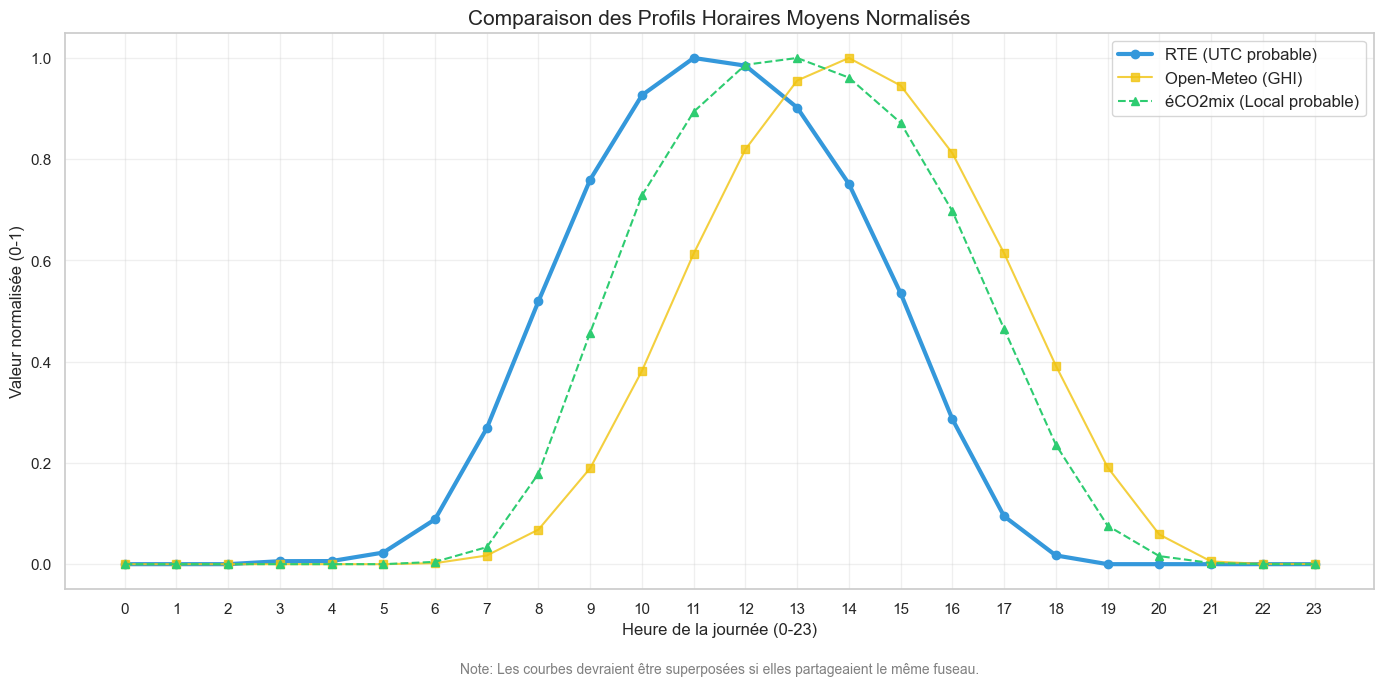

In [3]:
# 1. Préparation des moyennes horaires
df_hourly = df.groupby('heure')[['solar_production_mw', 'ghi', 'solar_production_mw_csv']].mean()

# 2. Normalisation Min-Max (0-1) pour comparer les formes
df_norm = (df_hourly - df_hourly.min()) / (df_hourly.max() - df_hourly.min())

# 3. Graphique superposé
plt.figure(figsize=(14, 7))
plt.plot(df_norm.index, df_norm['solar_production_mw'], label='RTE (UTC probable)', marker='o', linewidth=3, color='#3498db')
plt.plot(df_norm.index, df_norm['ghi'], label='Open-Meteo (GHI)', marker='s', alpha=0.8, color='#f1c40f')
plt.plot(df_norm.index, df_norm['solar_production_mw_csv'], label='éCO2mix (Local probable)', marker='^', linestyle='--', color='#2ecc71')

plt.title('Comparaison des Profils Horaires Moyens Normalisés', fontsize=15)
plt.xlabel('Heure de la journée (0-23)')
plt.ylabel('Valeur normalisée (0-1)')
plt.xticks(range(0, 24))
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Note explicative
plt.annotate('Note: Les courbes devraient être superposées si elles partageaient le même fuseau.', 
             xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

### Diagnostic du décalage

| Variable | Heure du Pic Maximum | Observation |
|----------|----------------------|-------------|
| **RTE (Production)** | **11h** | Référence UTC. |
| **éCO2mix (CSV)** | **13h** | Décalage de **+2 heures** par rapport à RTE. |
| **Open-Meteo (GHI)** | **14h** | Décalage de **+3 heures** par rapport à RTE. |

**Analyse :**
1. Le décalage de **2 heures** entre RTE et éCO2mix correspond exactement à la différence entre l'heure **UTC** et l'heure **CEST** (Heure d'été en France, en vigueur sur la majorité du dataset d'avril).
2. Le décalage de **3 heures** pour l'irradiance suggère que les données météo sont soit calées sur un autre fuseau, soit qu'elles subissent un post-traitement de moyenne glissante créant un retard artificiel.

### Proposition de Correction

Pour aligner ces sources dans le pipeline industriel, nous devons standardiser le fuseau horaire dès la collecte.

**Action corrective recommandée :**
*   **Fichier** : `collectors/csv_collector.py` (ou `aggregator.py`)
*   **Modification** : Soustraire le décalage horaire dynamique lors du chargement du CSV pour le ramener en UTC, ou utiliser `pd.to_datetime(df['timestamp']).dt.tz_localize('Europe/Paris').dt.tz_convert('UTC')`.
*   **Impact** : Cela garantira que le pic de production RTE (physique) coïncide exactement avec le pic d'irradiance et la production déclarée régionalement.